# **Notebook 3a: Finetuning RobBERT on the manually labeled train dataset**

## 1. Importing the packages

In [ ]:
import os
import json
import random
import zipfile

import numpy as np
import pandas as pd
from datasets import Dataset

import torch
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

from google.colab import files

# Setting seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## 2. Loading the data (train and val splits)

In [ ]:
train_df = pd.read_csv("labeled_train.csv")
val_df = pd.read_csv("labeled_val.csv")

train_df["blurb_id"] = train_df["blurb_id"].astype(int)
val_df["blurb_id"] = val_df["blurb_id"].astype(int)

# Dropping columns not used for training
drop_cols = [c for c in ["sent_position", "final_edit"] if c in train_df.columns]
train_df = train_df.drop(columns=drop_cols)
val_df = val_df.drop(columns=drop_cols)

print(f"Train: {len(train_df)} sentences, {train_df['blurb_id'].nunique()} blurbs, "
      f"{train_df['unnecessary'].mean():.1%} positive")
print(f"Val:   {len(val_df)} sentences, {val_df['blurb_id'].nunique()} blurbs, "
      f"{val_df['unnecessary'].mean():.1%} positive")

Train: 1104 sentences, 119 blurbs, 28.5% positive
Val:   302 sentences, 29 blurbs, 26.5% positive


## 3. Checking token-length distribution

In [ ]:
MODEL_NAME = "pdelobelle/robbert-v2-dutch-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer class : {type(tokenizer).__name__}")
print(f"Vocab size      : {tokenizer.vocab_size}")
print(f"Special tokens  : {tokenizer.special_tokens_map}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer class : RobertaTokenizer
Vocab size      : 40000
Special tokens  : {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


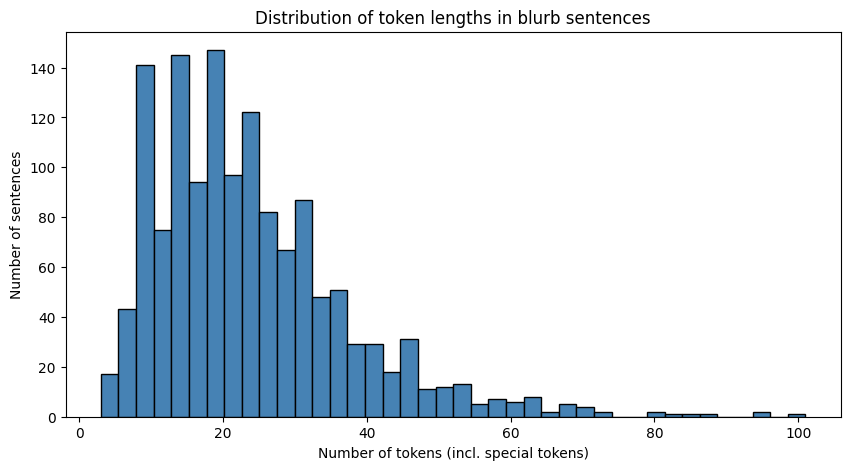

Sentences with > 100 tokens: 1 (0.07%)


In [ ]:
def count_tokens(s):
    """Token count INCLUDING special tokens."""
    if not isinstance(s, str) or not s.strip():
        return 0
    return len(tokenizer.encode(s, add_special_tokens=True, truncation=False))

# Combining train + val to inspect length distribution
all_sents = pd.concat([train_df["blurb_sent"], val_df["blurb_sent"]], ignore_index=True)
token_counts = all_sents.fillna("").apply(count_tokens)

plt.figure(figsize=(10, 5))
plt.hist(token_counts, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Number of tokens (incl. special tokens)")
plt.ylabel("Number of sentences")
plt.title("Distribution of token lengths in blurb sentences")
plt.show()

THRESHOLD = 100
n_above = (token_counts > THRESHOLD).sum()
pct_above = n_above / len(token_counts) * 100
print(f"Sentences with > {THRESHOLD} tokens: {n_above} ({pct_above:.2f}%)")

## 4. Settings

In [ ]:
# Model: RobBERT
MODEL_NAME = "pdelobelle/robbert-v2-dutch-base"

# MAX_LENGTH: 100 covers 99.86% of sentences in development
MAX_LENGTH = 100
LEARNING_RATE = 2e-5
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 8
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.15
MAX_GRAD_NORM = 1.0
EARLY_STOP_PATIENCE = 3

TRAIN_SEED = 42
OUTPUT_DIR = "./model_1"


# Class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["unnecessary"].values)
CLASS_WEIGHTS = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights: unnecessary={CLASS_WEIGHTS[0]:.3f}, necessary={CLASS_WEIGHTS[1]:.3f}")

Class weights: unnecessary=0.700, necessary=1.752


## 5. Setup helpers

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
set_seed(TRAIN_SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize(batch):
    return tokenizer(batch["blurb_sent"], truncation=True, max_length=MAX_LENGTH)

def df_to_dataset(d):
    ds = Dataset.from_pandas(
        d[["blurb_sent", "unnecessary"]].rename(columns={"unnecessary": "labels"}),
        preserve_index=False,)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    """Compute AUC on validation set during training."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = 0.5

    return {"auc": auc}

## 6. Training

In [ ]:
train_ds = df_to_dataset(train_df)
val_ds = df_to_dataset(val_df)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Arguments
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    max_grad_norm=MAX_GRAD_NORM,
    # Evaluation and checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    # Best model selection on val loss
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    # Logging
    logging_steps=50,
    report_to="none",
    # Reproducibility and precision
    seed=TRAIN_SEED,
    fp16=False,
    bf16=False,
    optim="adamw_torch",)

# Trainer
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = CrossEntropyLoss(
            weight=CLASS_WEIGHTS.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],)


print("Starting training...")
trainer.train()
print("\nTraining done.")

Map:   0%|          | 0/1104 [00:00<?, ? examples/s]

Map:   0%|          | 0/302 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: pdelobelle/robbert-v2-dutch-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training done.


## 7. Save model, predictions, and logs

In [ ]:
# Saving trained model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Saving val predictions for evaluation notebook
val_predictions = trainer.predict(val_ds)
np.save(os.path.join(OUTPUT_DIR, "val_logits.npy"), val_predictions.predictions)
np.save(os.path.join(OUTPUT_DIR, "val_labels.npy"), val_df["unnecessary"].values)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_data.csv"), index=False)

# Saving training log
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(os.path.join(OUTPUT_DIR, "training_log.csv"), index=False)

print(f"Saved to {OUTPUT_DIR}/:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./model_1/:
  threshold.json
  config.json
  tokenizer_config.json
  val_labels.npy
  val_logits.npy
  val_data.csv
  training_log.csv
  model.safetensors
  tokenizer.json
  test_probs.npy
  test_labels.npy
  checkpoint-138
  checkpoint-276
  checkpoint-345
  training_args.bin


Deleted after zip with final model is uploaded

## 8. Tuning model on validation data

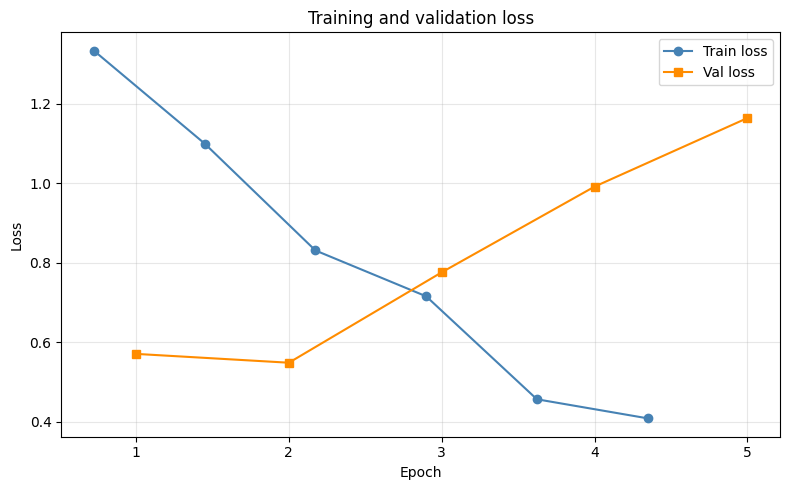

In [ ]:
# Loss plot
log_df = pd.read_csv(os.path.join(OUTPUT_DIR, "training_log.csv"))
train_log = log_df[log_df["loss"].notna() & log_df["eval_loss"].isna()]
eval_log  = log_df[log_df["eval_loss"].notna()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_log["epoch"], train_log["loss"], "o-", label="Train loss", color="steelblue")
ax.plot(eval_log["epoch"], eval_log["eval_loss"], "s-", label="Val loss", color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

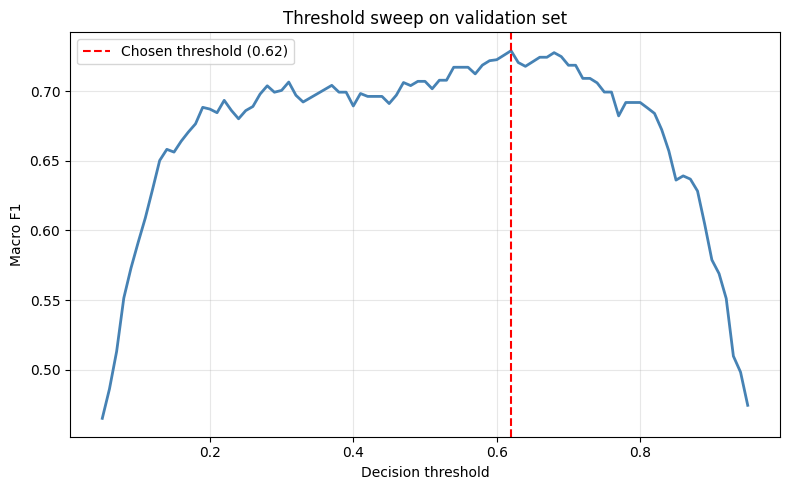

Chosen threshold: 0.62 (Macro F1=0.729)


In [ ]:
# Threshold decisions based on macro f1

val_logits = np.load(os.path.join(OUTPUT_DIR, "val_logits.npy"))
val_labels = np.load(os.path.join(OUTPUT_DIR, "val_labels.npy"))
val_probs  = F.softmax(torch.tensor(val_logits), dim=-1).numpy()[:, 1]

threshold_grid = np.arange(0.05, 0.96, 0.01)
rows = []
for t in threshold_grid:
    preds = (val_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "f1_macro":  f1_score(val_labels, preds, average="macro", zero_division=0),})

sweep_df = pd.DataFrame(rows)

best_idx = sweep_df["f1_macro"].idxmax()
CHOSEN_THRESHOLD = sweep_df.loc[best_idx, "threshold"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df["threshold"], sweep_df["f1_macro"], linewidth=2, color="steelblue")
ax.axvline(CHOSEN_THRESHOLD, color="red", linestyle="--", label=f"Chosen threshold ({CHOSEN_THRESHOLD:.2f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Macro F1")
ax.set_title("Threshold sweep on validation set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Chosen threshold: {CHOSEN_THRESHOLD:.2f} (Macro F1={sweep_df.loc[best_idx, 'f1_macro']:.3f})")

## 9. Downloading results as zip

In [ ]:
with open(os.path.join(OUTPUT_DIR, "threshold.json"), "w") as f:
    json.dump({"threshold": float(CHOSEN_THRESHOLD)}, f)

zip_path = "/content/model_1.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in ["val_logits.npy", "val_labels.npy", "val_data.csv",
                  "training_log.csv", "threshold.json"]:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            print(f"Added: {fname}")

    # Save model files
    model_files = [f for f in os.listdir(OUTPUT_DIR)
                   if f.endswith(".safetensors") or f in
                   ["config.json", "tokenizer_config.json", "vocab.txt",
                    "special_tokens_map.json", "tokenizer.json"]]
    for fname in model_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            print(f"Added: {fname}")

print(f"\nZip size: {os.path.getsize(zip_path) / 1024:.1f} KB")
files.download(zip_path)

Added: val_logits.npy
Added: val_labels.npy
Added: val_data.csv
Added: training_log.csv
Added: threshold.json
Added: config.json
Added: tokenizer_config.json
Added: model.safetensors
Added: tokenizer.json

Zip size: 423664.8 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>